# Project Marketing Analytics
Author: *Colombini Francesco*

Student ID: *944941*

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from src.preprocessing import (
    load_datasets,
    dataset_overview,
    find_best_organisation,
    select_firm,
    handle_missing_values,
    identify_media_channels,
    save_table,

    ## PLOTS
    plot_all_purchases_original_price,
    plot_missing_heatmap,
    plot_channel_spend,
    plot_media_spend_trends,
    plot_correlation_heatmap,
    plot_partial_correlation_heatmap,
    plot_spend_concentration,
    plot_seasonality,
    plot_outliers,
)

from src.modeling import (
    prepare_mmm_dataset,
    temporal_train_test_split,
    align_geo_dates,
    compute_empirical_roi,
    build_meridian_input_data,
    build_holdout_id,
    build_and_train_meridian,
    evaluate_meridian_model,
    plots_MMM,
    save_model,
    load_model,
)

from src.roi import (
    build_return_on_investment_table,
    investment_evaluation_channel,
)

from src.shap_analysis import (
    build_shap_input,
    get_geo_contributions,
    plot_shap_importance,
    plot_shap_summary,
    plot_shap_dependence,
    #combine_geo_plots,
    print_credible_intervals,
)

from src.scenarios import (
    get_channel_metrics,
    strategy_equal_allocation,
    strategy_mroi_optimized,
    strategy_saturation_aware
)

from src.optimization import (
    run_budget_optimization,
    save_optimization_results,
    load_optimization_results,
    print_optimization_summary,
)

In [2]:
FILE_PATH = '../data/conjura_mmm_data.csv'
data = load_datasets(FILE_PATH)
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Analysis full dataset

### Task 1 - Exploratory Data Analysis

In [3]:
dataset_overview(data)

Dataset shape: (132759, 50)

Missing values in dataset:
MMM_TIMESERIES_ID                           0
ORGANISATION_ID                             0
ORGANISATION_VERTICAL                    8110
ORGANISATION_SUBVERTICAL                 8110
ORGANISATION_MARKETING_SOURCES              0
ORGANISATION_PRIMARY_TERRITORY_NAME         0
TERRITORY_NAME                              0
DATE_DAY                                    0
CURRENCY_CODE                               0
FIRST_PURCHASES                             0
FIRST_PURCHASES_UNITS                       0
FIRST_PURCHASES_ORIGINAL_PRICE              0
FIRST_PURCHASES_GROSS_DISCOUNT              0
ALL_PURCHASES                               0
ALL_PURCHASES_UNITS                         0
ALL_PURCHASES_ORIGINAL_PRICE                0
ALL_PURCHASES_GROSS_DISCOUNT                0
GOOGLE_PAID_SEARCH_SPEND                36122
GOOGLE_SHOPPING_SPEND                   53779
GOOGLE_PMAX_SPEND                       71633
GOOGLE_DISPLAY_SPEND    

In [4]:
media_channels = identify_media_channels(data)

Missing value heatmap is not performed on an aggregate level.
Across 93 organisations, a missing value may indicate either an inactive channel or a tracking issue, making the pattern uninterpretable.

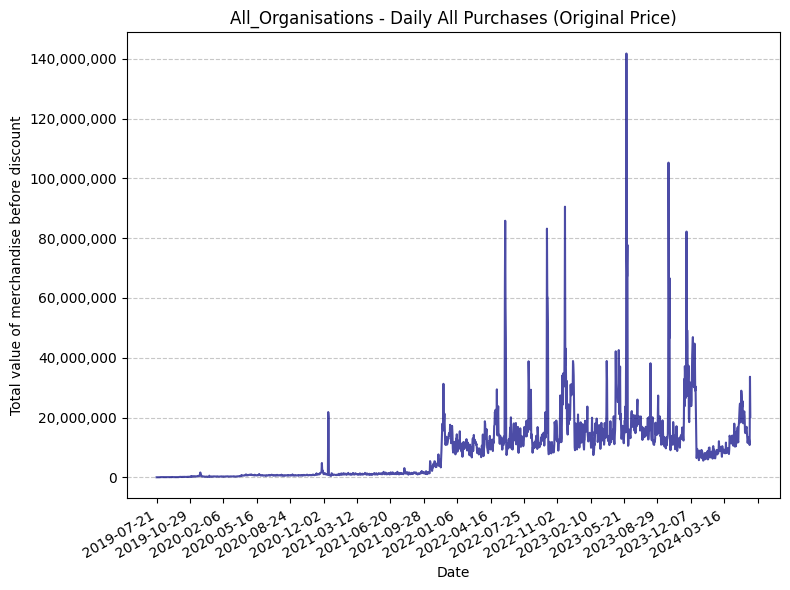

In [5]:
plot_all_purchases_original_price(data, "All_Organisations")

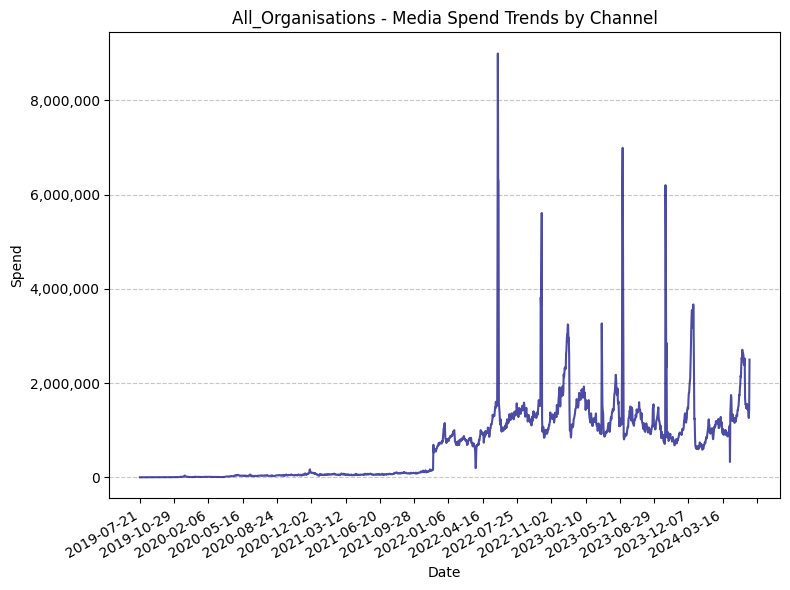

In [6]:
plot_media_spend_trends(data, "All_Organisations")

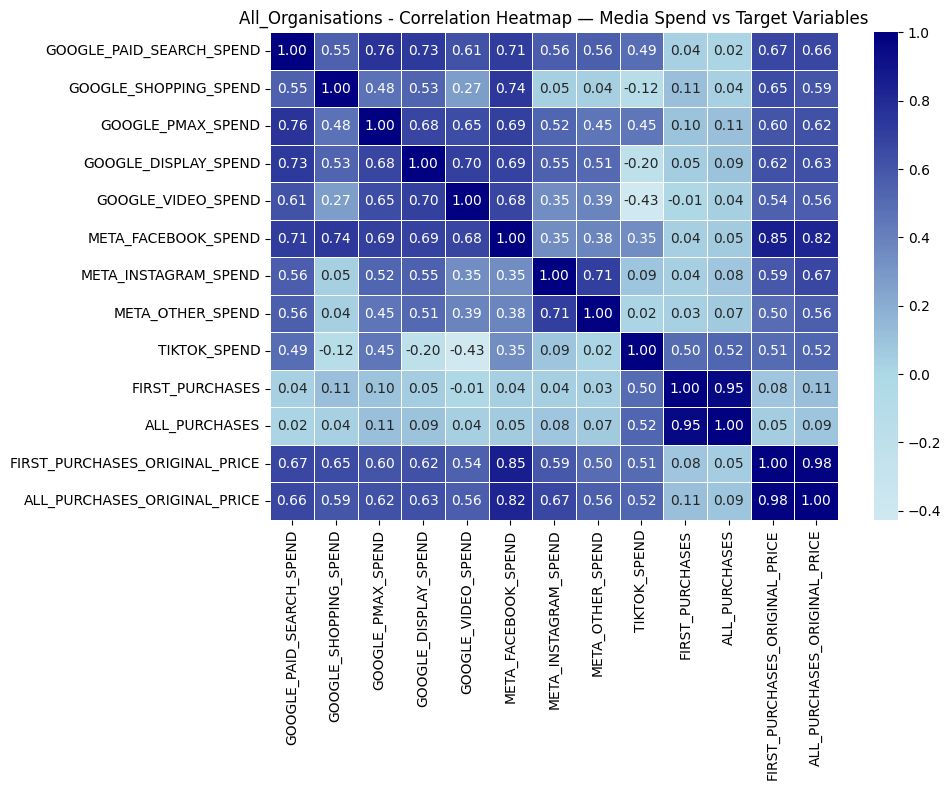

In [7]:
plot_correlation_heatmap(data, "All_Organisations")

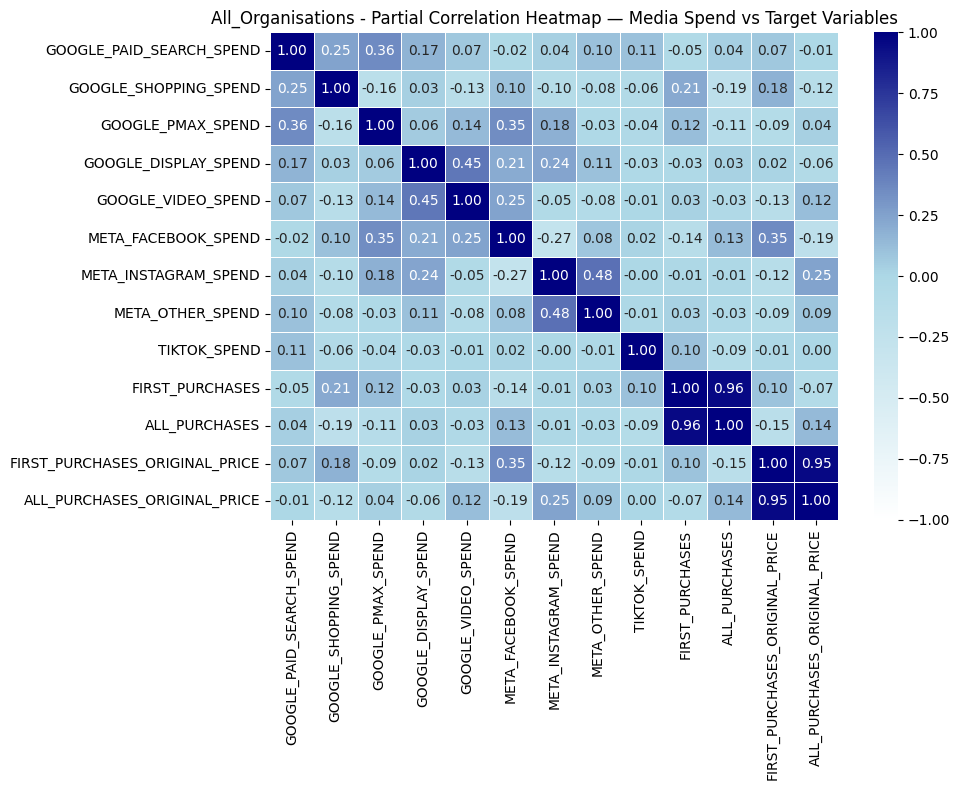

In [8]:
plot_partial_correlation_heatmap(data, "All_Organisations")

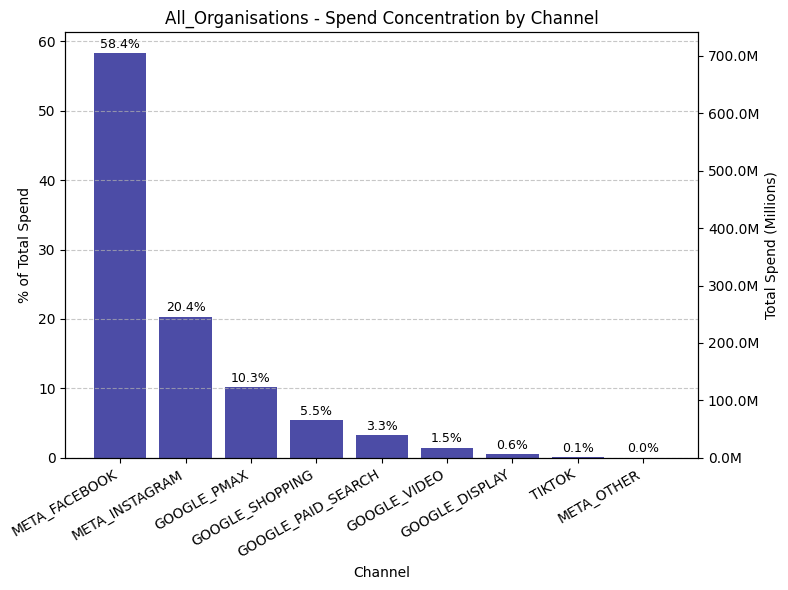

In [9]:
plot_spend_concentration(data, "All_Organisations")

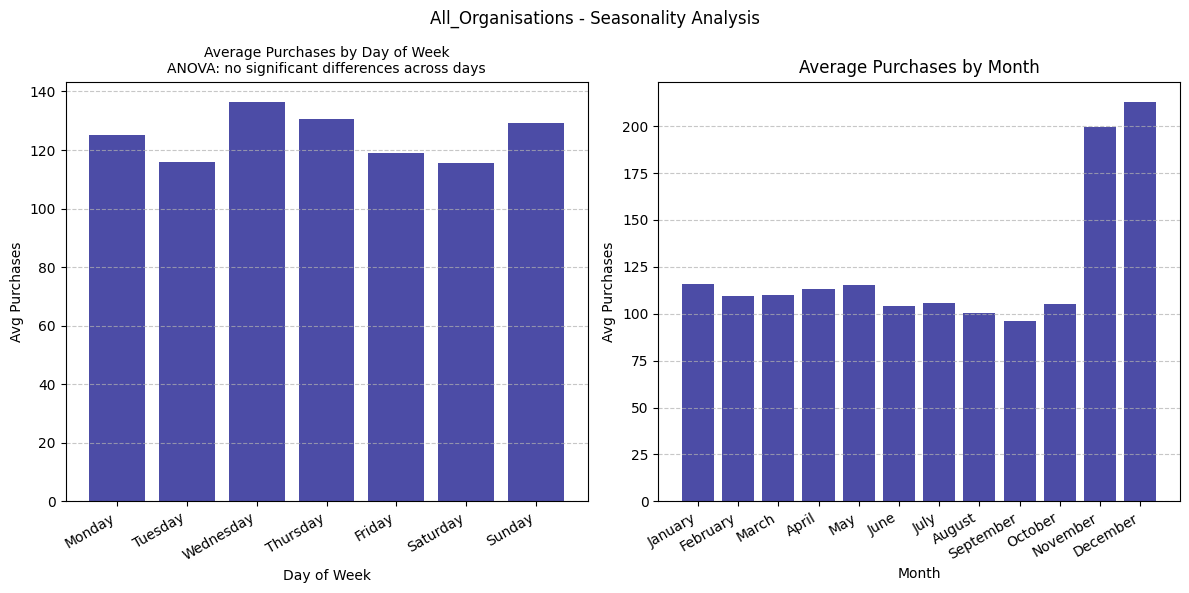

In [10]:
plot_seasonality(data, "All_Organisations")

Outlier detection is performed on a single organisation only.
Aggregating across 93 organisations would produce incomparable distributions due to different spend scales.

### Task 2 - Data Preparation

In [11]:
ready_dataset = prepare_mmm_dataset(data, media_channels)
#print(ready_dataset.head())

In [12]:
train_full_df, test_full_df = temporal_train_test_split(ready_dataset)

Train set: 2019-07-21 00:00:00 to 2023-06-29 00:00:00 (99569 rows)
Validation set: 2023-06-29 00:00:00 to 2024-06-02 00:00:00 (33190 rows)
OK! Train set covers 206 weeks
OK! Train set has 9 active media channels
OK! Target variable NET_REVENUE present
OK! Time control variables present


## Single firm analysis

### Task 1 - Exploratory Data Analysis

In [13]:
best_org = find_best_organisation(data)
org_id = best_org.strip()
df_org = select_firm(data, org_id)

                     organisation_id  date_range_days  active_channels  rows
53  784d6aa3cda59f59f2400332b2420a49           1414.0                7  2804
50  7569a6a9c156a0f9398fa6cfd51df5bb            820.0                7  2095
90  f7e5ba45e3e337e8e90787ae0218a7ac           1090.0                6  1789
36  4a762f02ca755b22d37393e8dbeab1a6           1029.0                6  1970
1   058b38dc1b5a87a8d9338196cd024d47            457.0                6   916
18  246b6e2ff861fde47d3bc5f5fdae92a8            765.0                5  1520
56  7c374835f86c472c74023b035b9deef0            985.0                4  1697
87  eee3213700d652277941b8370c8c4dcf            944.0                4  2459
76  c5fbe353800204351f2768f90d703b38            570.0                4  1713
59  882ce7e286d66facc66518783e2192c7           1710.0                3  7631
Territories: ['UK' 'US']
Date range: 2020-04-21 to 2024-03-05
Rows: 2804
Rows per territory:
TERRITORY_NAME
US    1415
UK    1389
Name: count, dtype: int

In [14]:
media_channels_org = identify_media_channels(df_org)

In [15]:
dataset_overview(df_org)

Dataset shape: (2804, 50)

Missing values in dataset:
MMM_TIMESERIES_ID                         0
ORGANISATION_ID                           0
ORGANISATION_VERTICAL                     0
ORGANISATION_SUBVERTICAL                  0
ORGANISATION_MARKETING_SOURCES            0
ORGANISATION_PRIMARY_TERRITORY_NAME       0
TERRITORY_NAME                            0
DATE_DAY                                  0
CURRENCY_CODE                             0
FIRST_PURCHASES                           0
FIRST_PURCHASES_UNITS                     0
FIRST_PURCHASES_ORIGINAL_PRICE            0
FIRST_PURCHASES_GROSS_DISCOUNT            0
ALL_PURCHASES                             0
ALL_PURCHASES_UNITS                       0
ALL_PURCHASES_ORIGINAL_PRICE              0
ALL_PURCHASES_GROSS_DISCOUNT              0
GOOGLE_PAID_SEARCH_SPEND               1148
GOOGLE_SHOPPING_SPEND                  1860
GOOGLE_PMAX_SPEND                      1941
GOOGLE_DISPLAY_SPEND                   1343
GOOGLE_VIDEO_SPEND    

Missing percentage per channel:
TIKTOK_SPEND                100.0
GOOGLE_VIDEO_SPEND           95.3
GOOGLE_PMAX_SPEND            69.2
GOOGLE_SHOPPING_SPEND        66.3
GOOGLE_DISPLAY_SPEND         47.9
GOOGLE_PAID_SEARCH_SPEND     40.9
META_OTHER_SPEND             36.0
META_INSTAGRAM_SPEND         35.3
META_FACEBOOK_SPEND           9.6
dtype: float64


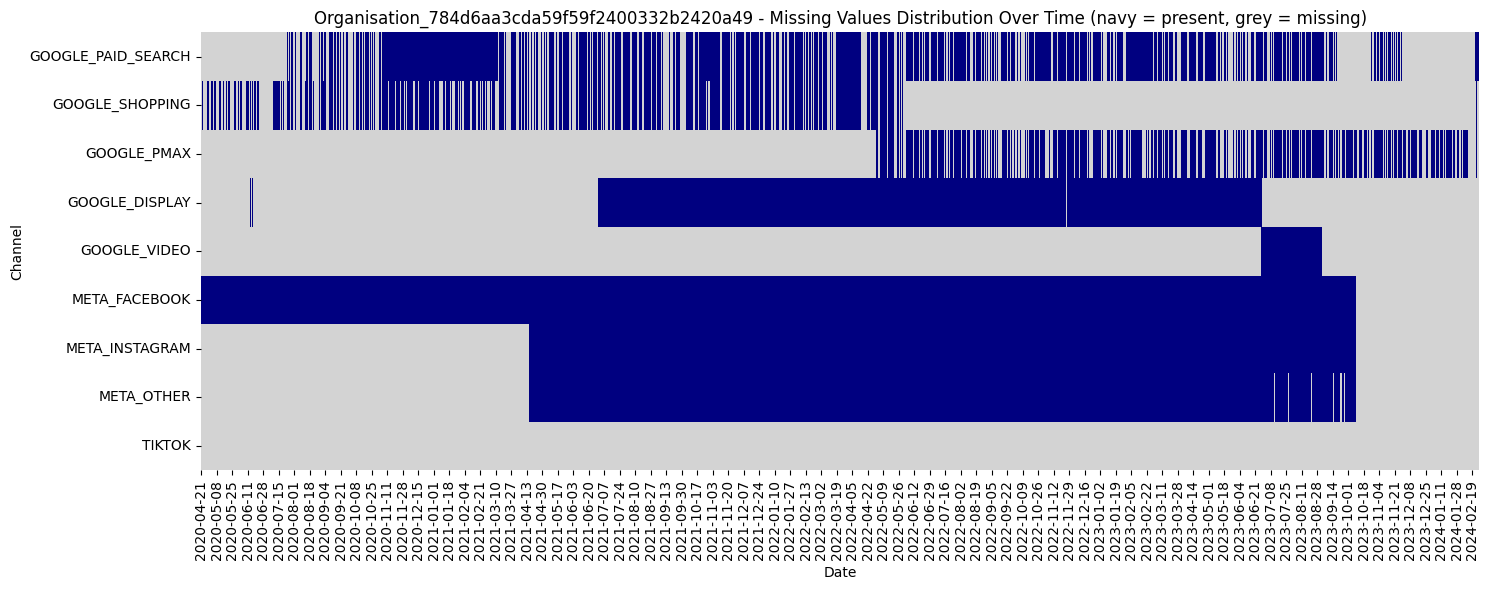

In [16]:
plot_missing_heatmap(df_org, f"Organisation_{org_id}")

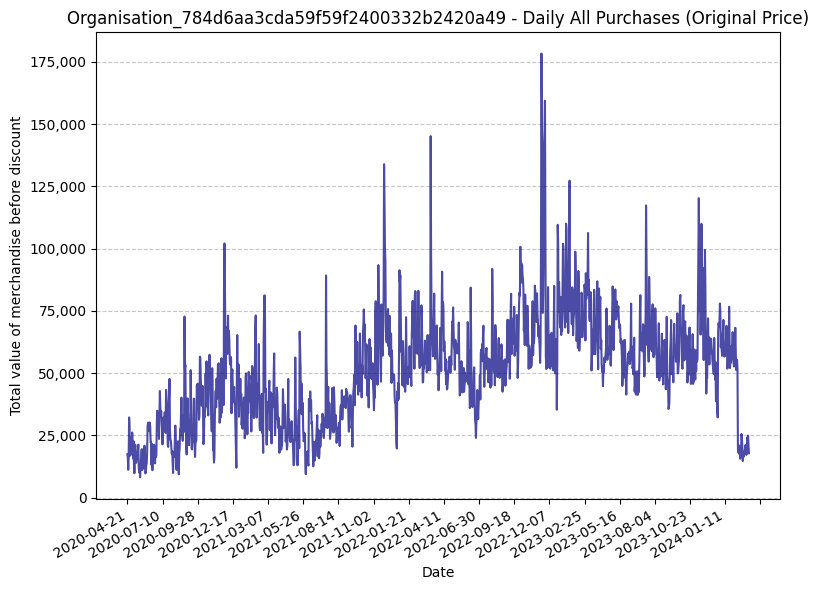

In [17]:
plot_all_purchases_original_price(df_org, f"Organisation_{org_id}")

In [18]:
clean_df = handle_missing_values(df_org)

Dropped channels: ['GOOGLE_SHOPPING', 'GOOGLE_PMAX', 'GOOGLE_VIDEO', 'TIKTOK']
Filled with 0: ['GOOGLE_PAID_SEARCH', 'GOOGLE_DISPLAY', 'META_FACEBOOK', 'META_INSTAGRAM', 'META_OTHER']


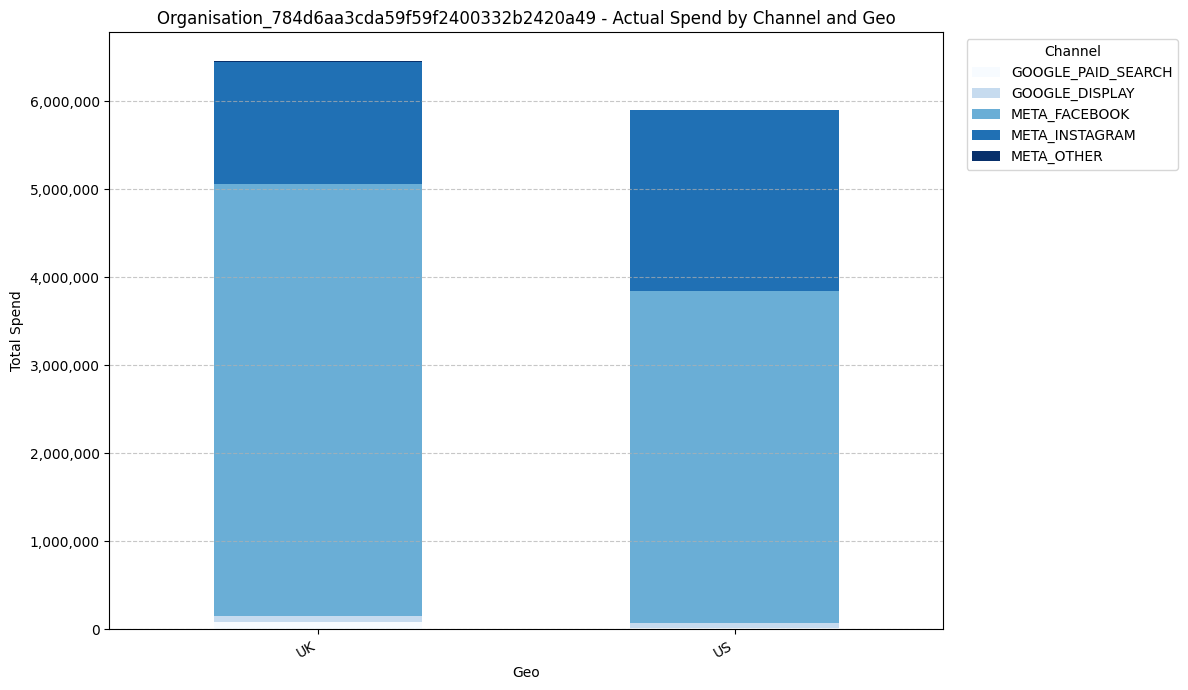

saved csv: C:\Documenti\UNIMIB\Marketing Analytics\Project_fcolombini4\outputs\tables\Organisation_784d6aa3cda59f59f2400332b2420a49_actual_spend_by_channel_geo.csv
                GOOGLE_PAID_SEARCH  GOOGLE_DISPLAY  META_FACEBOOK  \
TERRITORY_NAME                                                      
UK                        84856.85        57980.82      4916769.6   
US                        13576.27        55449.27      3776218.9   

                META_INSTAGRAM  META_OTHER  
TERRITORY_NAME                              
UK                  1379157.25    18786.06  
US                  2052001.72     5927.82  


In [19]:
spend_table = plot_channel_spend(clean_df, f"Organisation_{org_id}")
print(spend_table)

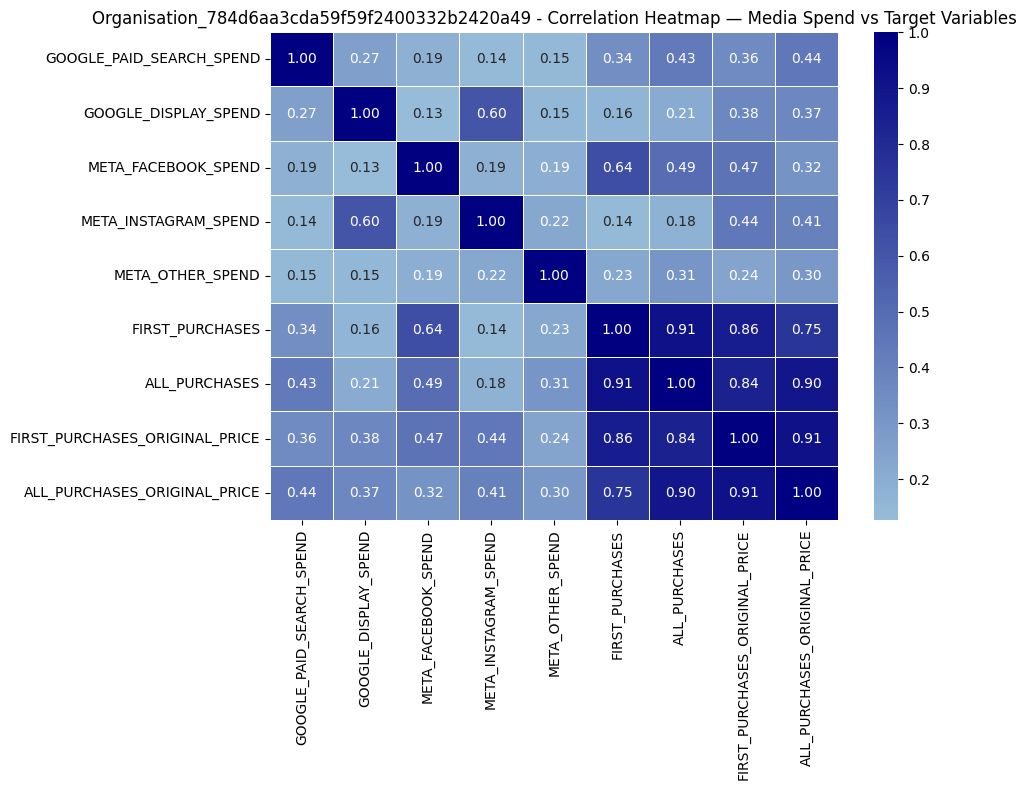

In [20]:
plot_correlation_heatmap(clean_df, f"Organisation_{org_id}")

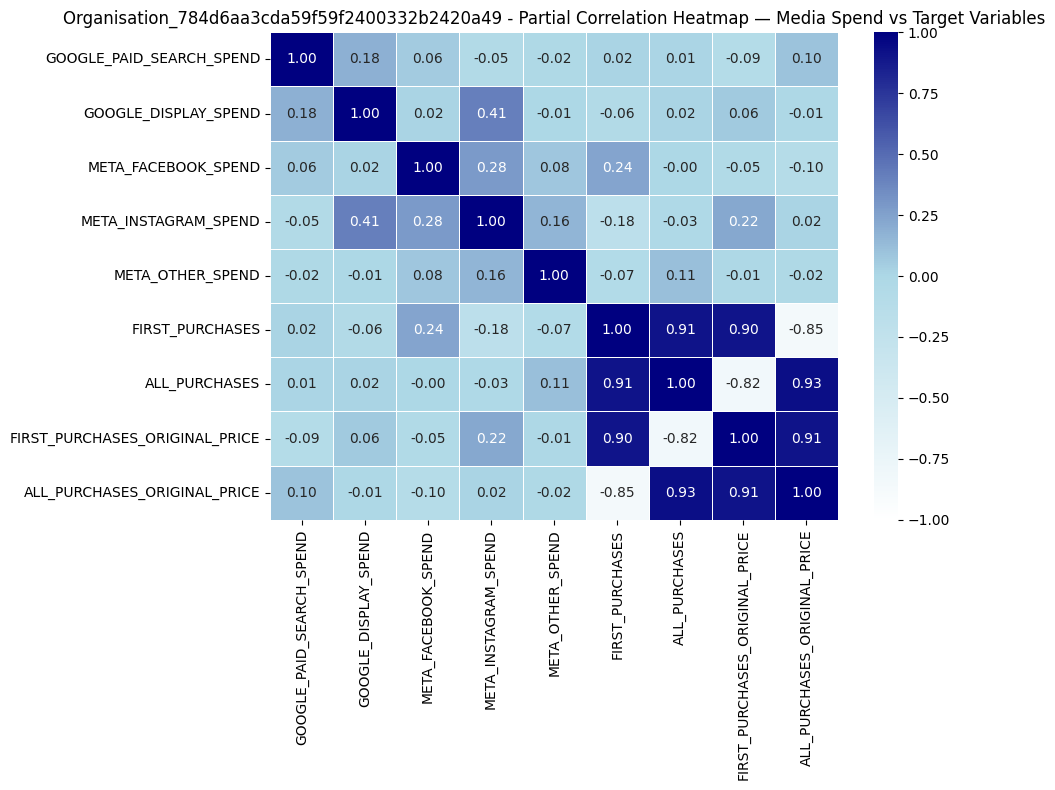

In [21]:
plot_partial_correlation_heatmap(clean_df, f"Organisation_{org_id}")

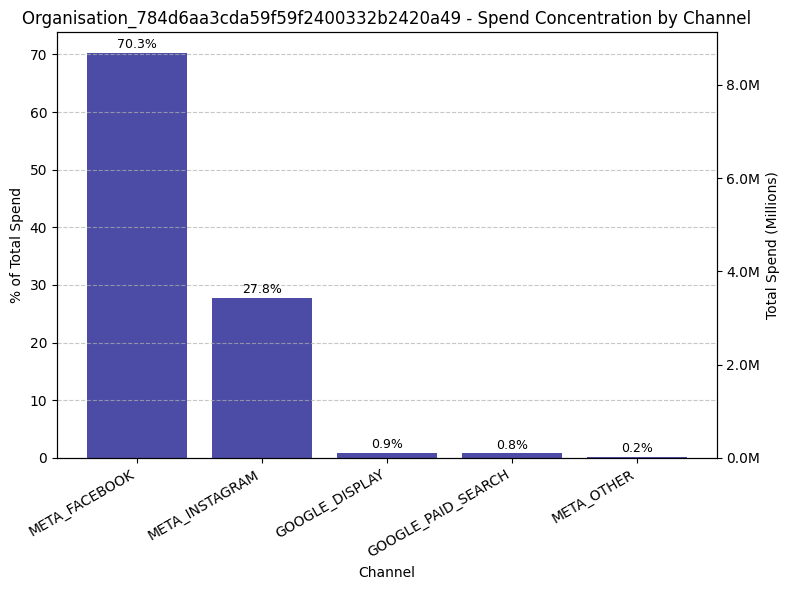

In [22]:
plot_spend_concentration(clean_df, f"Organisation_{org_id}")

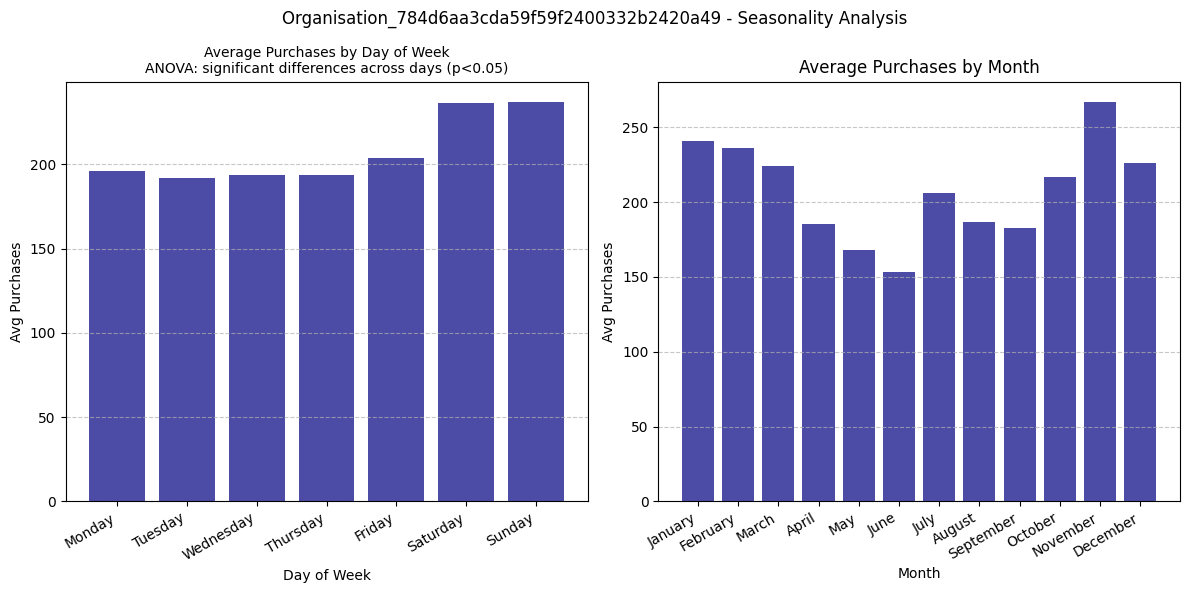

In [23]:
plot_seasonality(clean_df, f"Organisation_{org_id}")

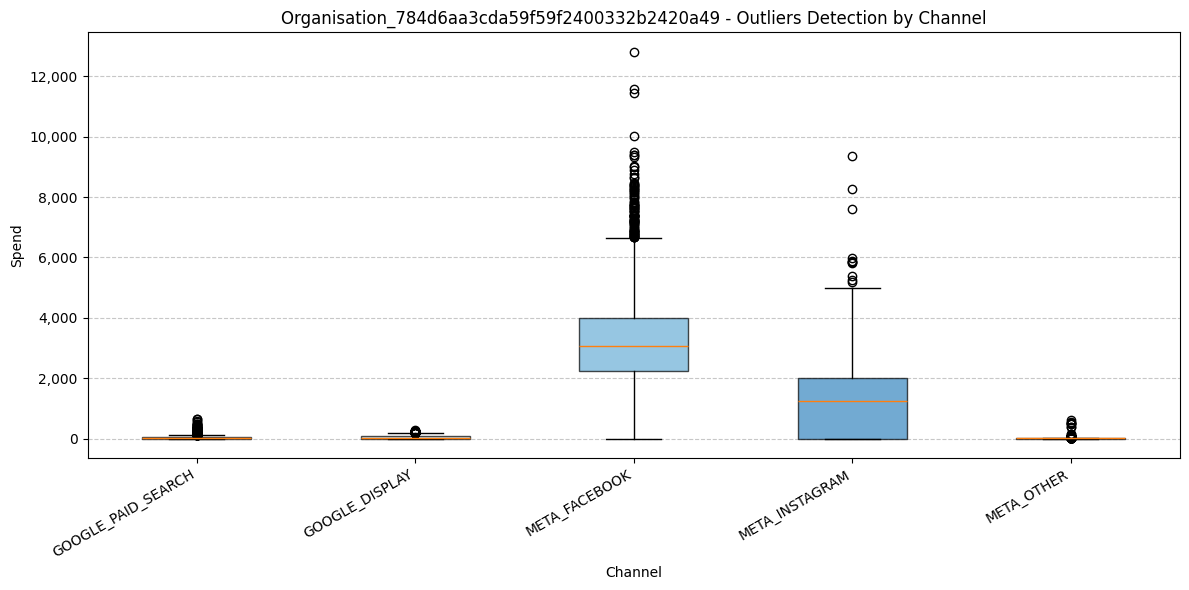

In [24]:
plot_outliers(clean_df, f"Organisation_{org_id}")

### Task 2 — Data Preparation

In [25]:
ready_org = prepare_mmm_dataset(clean_df, media_channels_org)
#print(ready_org.head())

In [26]:
train_org_df, test_org_df = temporal_train_test_split(ready_org)

Train set: 2020-04-21 00:00:00 to 2023-03-08 00:00:00 (2103 rows)
Validation set: 2023-03-08 00:00:00 to 2024-03-05 00:00:00 (701 rows)
OK! Train set covers 150 weeks
OK! Train set has 5 active media channels
OK! Target variable NET_REVENUE present
OK! Time control variables present


In [27]:
train_org_df = align_geo_dates(train_org_df)
test_org_df = align_geo_dates(test_org_df)

Geos: ['UK', 'US']
  UK: 1051 rows
  US: 1051 rows
Geos: ['UK', 'US']
  UK: 337 rows
  US: 337 rows


In [28]:
empirical_roi = compute_empirical_roi(train_org_df)

Total spend: 10184034.92
Total revenue: 49344153.25
Empirical ROI (global): 4.8452
  UK ROI: 5.6675
  US ROI: 3.8824


### Task 3 - Meridian MMM Model Development

In [29]:
#holdout_id = build_holdout_id(train_org_df, train_ratio=0.75)
#input_data_org = build_meridian_input_data(train_org_df, media_channels_org)
#mmm = build_and_train_meridian(input_data_org, empirical_roi)

In [30]:
#save_model(mmm)

In [31]:
mmm =load_model()

Model loaded from ../outputs/model/mmm_model.binpb


In [32]:
print(mmm.input_data.media_channel.values)

['GOOGLE_DISPLAY' 'META_FACEBOOK' 'META_INSTAGRAM' 'META_OTHER']


In [33]:
evaluate_meridian_model(mmm)

Model performance metrics:
                              value
metric    geo_granularity          
R_Squared geo              0.777868
          national         0.772496
MAPE      geo              0.218092
          national         0.165473
wMAPE     geo              0.179113
          national         0.151440


In [34]:
plots_MMM(mmm)

c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\altair\utils\core.py:384: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\altair\utils\core.py:384: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


Saved: ../outputs/charts/Meridian_model_fit.png
Saved: ../outputs/charts/Meridian_response_curves.png


The model is configured as a geo-level MMM: rather than aggregating UK and US into a single national model, Meridian estimates channel contributions, ROI, and mROI separately for each territory. This is achieved by passing `aggregate_geos=False` throughout the analysis pipeline.

Territory-specific modeling is important because media efficiency can differ significantly across markets, a channel that is saturated in the US may still have room to grow in the UK, and vice versa.

### Task 4 - ROI and Marginal ROI Analysis

In [35]:
mroi_results = build_return_on_investment_table(mmm, kind="mroi")
print(mroi_results)

                mROI Median  mROI 2.5%  mROI 97.5%
Channel                                           
GOOGLE_DISPLAY     0.874528   0.113181    2.285908
META_FACEBOOK      2.322976   1.200468    2.672713
META_INSTAGRAM     1.570513   0.329155    3.588170
META_OTHER         2.594648   1.961245    4.173600


In [36]:
roi_results = build_return_on_investment_table(mmm, kind="roi")
print(roi_results)


                ROI Median  ROI 2.5%  ROI 97.5%
Channel                                        
GOOGLE_DISPLAY    2.537318  0.202345   5.757765
META_FACEBOOK     3.317438  1.891167   3.511793
META_INSTAGRAM    2.084299  0.482038   4.836885
META_OTHER        4.971024  4.226224   6.708432


In [37]:
save_table(roi_results, "roi_table")
save_table(mroi_results, "mroi_table")

Table saved to ../outputs/tables\roi_table.csv
Table saved to ../outputs/tables\mroi_table.csv


In [38]:
invested_channels = investment_evaluation_channel(roi_results, mroi_results)

In [39]:
save_table(invested_channels, "invested_channels_table")

Table saved to ../outputs/tables\invested_channels_table.csv


All channels show mROI < ROI, which is the expected behavior under diminishing returns. This means that the last euro spent on each channel generates less revenue than the historical average. This gap indicates how far each channel is along its response curve.

`GOOGLE_DISPLAY` shows the most *severe saturation effect*, with mROI = 0.87, below the break-even threshold of 1. This means the last euro spent on this channel generates less than 1€ in return, indicating the channel has reached a point of diminishing returns where additional investment destroys value.

The Meta channels (`META_FACEBOOK`, `META_INSTAGRAM`, `META_OTHER`) all show mROI > 1, suggesting they have not yet reached full saturation at current spend levels.

Based on the mROI threshold of 1:

In [40]:
invested_channels

,ROI Median,mROI Median,Status
Channel,,,
GOOGLE_DISPLAY,2.537318,0.874528,Over-invested
META_FACEBOOK,3.317438,2.322976,Under-invested
META_INSTAGRAM,2.084299,1.570513,Under-invested
META_OTHER,4.971024,2.594648,Under-invested


An efficient reallocation would shift budget from `GOOGLE_DISPLAY` toward the Meta channels, particularly `META_OTHER` which shows the highest mROI (2.59) and the highest ROI (4.97), indicating it is both the most efficient channel historically and still has room for further investment.

### Task 5 - SHAP Explainability

In [41]:
contributions, contributions_lower, contributions_upper, baseline, channels, geos = build_shap_input(mmm)

time_labels = list(mmm.input_data.time.values.astype(str))

for geo in geos:
    geo_contrib, geo_contrib_lower, geo_contrib_upper, geo_baseline = get_geo_contributions(
        contributions, contributions_lower, contributions_upper, baseline, geos, geo
    )

    plot_shap_importance(geo_contrib, channels, geo)
    plot_shap_summary(geo_contrib, channels, geo)
    plot_shap_dependence(mmm, geo_contrib, channels, geo)


c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:533: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\autograph\impl\api.py:371: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  return py_builtins.overload_of(f)(*args)


SHAP importance plot saved for UK
SHAP summary plot saved for UK
SHAP dependence plots saved for UK
SHAP importance plot saved for US
SHAP summary plot saved for US
SHAP dependence plots saved for US


In [42]:
intervals = print_credible_intervals(
    geo_contributions=geo_contrib,
    geo_contributions_lower=geo_contrib_lower,
    geo_contributions_upper=geo_contrib_upper,
    channels=channels,
    geo=geo
)


Bayesian Credible Intervals (95% CI) — US
                     median      ci_2.5%     ci_97.5%     ci_width
channel                                                           
GOOGLE_DISPLAY   112.208008    11.370131   274.246382   262.876251
META_FACEBOOK   7302.853027  5704.458761  8711.241006  3006.782244
META_INSTAGRAM  3143.969238   174.288189  5373.768600  5199.480411
META_OTHER        51.426731     3.944956    74.775314    70.830359


#### Channel importance
The feature importance bar charts (mean absolute SHAP value) tell us that in both territories META_FACEBOOK is the dominant revenue driver, but the degree of dominance is very different across the 2 markets.

In the UK market, META_FACEBOOK (15,816) accounts for roughly 89% of total SHAP importance across the four channels. Then follow META_INSTAGRAM (1,881) and GOOGLE_DISPLAY (113) and META_OTHER (68) are essentially negligible — both under 1% of total importance.
While in the US, META_FACEBOOK is still the top channel (7,303) but its lead is much narrower, roughly 70% of total importance, with META_INSTAGRAM playing a materially larger role (3,144, about 30%). GOOGLE_DISPLAY (112) and META_OTHER (51) are again negligible.

It is important to say that it must be considered that the spending of each channel is related with their importance, so an higher budget contribution (budget table below) could imply an higher SHAP result.

In [43]:
import pandas as pd

df = pd.read_csv("../outputs/tables/Organisation_784d6aa3cda59f59f2400332b2420a49_actual_spend_by_channel_geo.csv", encoding="utf-8")
print(df)

  TERRITORY_NAME  GOOGLE_PAID_SEARCH  GOOGLE_DISPLAY  META_FACEBOOK  \
0             UK            84856.85        57980.82      4916769.6   
1             US            13576.27        55449.27      3776218.9   

   META_INSTAGRAM  META_OTHER  
0      1379157.25    18786.06  
1      2052001.72     5927.82  


#### Time-series decomposition
Both "SHAP Over Time" charts decompose daily revenue into baseline (intercept + controls) and channel contributions and show that:
- META_FACEBOOK (purple) forms the dominant, persistent layer in both markets across the full 2020–2023 window, confirming it's not a one-off spike but a stable, structural revenue driver.
- META_INSTAGRAM (pink) is visibly thin in the UK chart but grows into a substantial, consistent band in the US chart from mid-2021 onward, visually corroborating the higher aggregate importance seen in the bar chart.
- GOOGLE_DISPLAY (green) and META_OTHER (cyan) sit essentially flat at/near zero throughout both time series, visually confirming they contribute little regardless of period, consistent with the saturation finding from the ROI/mROI analysis (GOOGLE_DISPLAY's mROI < 1).
- Baseline (blue) behaves differently by market: in the UK it's consistently positive, spiking noticeably around late 2021 and late 2022 (likely seasonal/promotional periods). In the US it dips negative in the early part of the series (~April–August 2020, down to about -5,000), meaning that in that window the model's non-media baseline pulled predicted revenue below what controls alone would suggest — media contributions had to do proportionally more work to explain observed revenue in that early period.

#### Summary Plots
The SHAP summary plots add a distributional view on top of the importance ranking:

- META_FACEBOOK shows a wide, continuous spread of SHAP values, from near zero up to ~28,000–30,000 in the UK and ~18,000 in the US, indicating its contribution is not just large on average but variable and impactful across many individual days, not driven by a handful of outliers.
- META_INSTAGRAM shows a narrower but still meaningful spread — up to ~6,000 in the UK versus ~10,000+ in the US, again reflecting Instagram's stronger role in the US.
- GOOGLE_DISPLAY and META_OTHER cluster tightly around zero in both markets, with almost no spread, visual confirmation that these channels rarely drive meaningful day-to-day revenue swings, reinforcing that GOOGLE_DISPLAY's low contribution isn't a modeling artifact but a consistent pattern across the full observation window.

### Task 6 - Marketing Investment Scenario Simulation

#### Scenario 1: Equal Allocation

In [44]:
metrics = get_channel_metrics(mmm, roi_results, mroi_results)
df_equal = strategy_equal_allocation(mmm, metrics, pct=0.20, df_cleaned=clean_df)
df_equal[["scenario_name", "delta_abs", "delta_pct", "incremental_purchases", "incremental_roi"]]

,scenario_name,delta_abs,delta_pct,incremental_purchases,incremental_roi
0,equal_allocation,2057051.0,6.888699,17092.036398,1.017592


The +20% extra budget is split equally across all channels regardless of performance. This is the naive baseline strategy without optimization, or prioritization

#### Scenario 2: Allocation based on highest mROI

In [45]:
df_mroi = strategy_mroi_optimized(mmm, metrics, pct=0.20, df_cleaned=clean_df)


Best channel by mROI: META_OTHER (mROI = 2.595)


The entire +20% extra budget is concentrated on META_OTHER, the channel with the highest mROI (2.59)
This maximizes marginal efficiency but ignores the channel's limited historical spend (€22k) As a result, Meridian's response curve saturates rapidly at these budget levels, producing a lower absolute uplift than equal allocation, a key finding on scalability vs efficiency

#### Scenario 3: Reduced investment in saturated channels

In [46]:
df_sat = strategy_saturation_aware(mmm, metrics, df_cleaned=clean_df)
df_sat[["scenario_name", "delta_abs", "delta_pct", "incremental_purchases", "incremental_roi"]]

,scenario_name,delta_abs,delta_pct,incremental_purchases,incremental_roi
0,saturation_aware,2508218.0,8.399577,20840.782922,1.240778


All scenarios share the same external extra budget (+20% of total historical spend = ~€2M) making delta_abs, incremental_purchases and incremental_roi directly comparable across rows. Scenario 3 also reallocates freed budget internally from saturated channels.

#### Total comparison

In [47]:
import pandas as pd
# final comparison table
summary = pd.concat([df_equal, df_mroi, df_sat], ignore_index=True)
print(summary[["scenario_name", "delta_abs", "incremental_purchases", "incremental_roi"]])

      scenario_name  delta_abs  incremental_purchases  incremental_roi
0  equal_allocation  2057051.0           17092.036398         1.017592
1    mroi_optimized   296755.0            2465.737243         0.146800
2  saturation_aware  2508218.0           20840.782922         1.240778


**Scenario 1: Equal Allocation** (incremental ROI: 1.02)
Distributing the +20% extra budget equally across all channels generates €2.06M of incremental revenue and ~17k additional purchases. An incremental ROI of 1.02 means that every extra euro spent returns approximately €1.02, slightly above break-even. This is the baseline strategy: simple to implement but suboptimal, as it ignores the very different efficiency levels across channels.

**Scenario 2: mROI-Optimized** (incremental ROI: 0.15)
Concentrating the entire extra budget on META_OTHER — the channel with the highest mROI (2.59), produces only €296k of incremental revenue and an incremental ROI of 0.15, well below break-even. The reason is structural, in fact META_OTHER represents only 0.2% of historical spend (€22k vs €10M total). Injecting €2M into a channel the model has never seen at that scale causes immediate saturation of the response curve. This result highlights a critical marketing insight: **marginal efficiency does not imply scalability**. The highest mROI channel is not necessarily the best recipient of a large budget injection.

**Scenario 3: Saturation-Aware** (incremental ROI: 1.24)
This is the best performing strategy. By cutting GOOGLE_DISPLAY (mROI = 0.87, the only saturated channel) by 30% and redistributing both the freed budget and the +20% extra to efficient channels weighted by mROI, the model generates €2.51M of incremental revenue and ~20.8k additional purchases, outperforming equal allocation by €450k with the same external budget. The incremental ROI of 1.24 confirms that combining internal reallocation with targeted external investment is the most effective approach when channel saturation is explicitly accounted for.

#### Best strategy
Saturation-aware reallocation wins on revenue, purchases, and ROI by combining the extra budget with an internal shift away from GOOGLE_DISPLAY.

Cautionary case:  As explained before concentrating all extra budget on META_OTHER looks very inefficient on the Meridian results, but the problem is that channel has limited historical spend and increasing the budget from 20K to over 2M saturates quickly and the results given are not reliable on the conclusion.  

## BONUS: Budget Optimization with Meridian optimizer



In [ ]:
results_optimization = run_budget_optimization(
    mmm,
    budget=None,
    spend_constraint_lower=0.5,
    spend_constraint_upper=2.0,
)
save_optimization_results(results_optimization)

c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:533: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\autograph\impl\api.py:371: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  return py_builtins.overload_of(f)(*args)
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:533: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:533: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  war

  Saved: ../outputs/charts/optimization_budget_allocation.jpg
  Saved: ../outputs/charts/optimization_spend_delta.jpg
  Saved: ../outputs/charts/optimization_outcome_delta.jpg

Full comparison — Historical vs Optimized:
                spend_historical  spend_optimized  spend_delta  spend_delta_pct  revenue_historical  revenue_optimized  revenue_delta  roi_historical  roi_optimized  mroi_optimized
channel                                                                                                                                                                             
GOOGLE_DISPLAY           90000.0          50000.0     -40000.0       -44.400002        2.337312e+05       1.847738e+05  -4.895744e+04        2.597013       3.695476        1.647891
META_FACEBOOK          7460000.0        8160000.0     700000.0         9.400000        2.474571e+07       2.633532e+07   1.589612e+06        3.317119       3.227368        2.208039
META_INSTAGRAM         2530000.0        1850000.0    -68

C:\Documenti\UNIMIB\Marketing Analytics\Project_fcolombini4\src\optimization.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(channels, rotation=30, ha='right')
C:\Documenti\UNIMIB\Marketing Analytics\Project_fcolombini4\src\optimization.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(channels, rotation=30, ha='right')


In [65]:
opt_df, nonopt_df = load_optimization_results()
print_optimization_summary(opt_df, nonopt_df)

Optimization results loaded from ../outputs/tables
Total budget (fixed) : $  10,100,000
Revenue before       : $  30,360,936 ROI: 3.01
Revenue after        : $  30,780,251 ROI: 3.05
Gain                 : $     419,315 (+1.4%)

Budget reallocation:
GOOGLE_DISPLAY       Decrease $   -40,000 (from $    90,000 to $    50,000)
META_FACEBOOK        Increase $  +700,000 (from $ 7,460,000 to $ 8,160,000)
META_INSTAGRAM       Decrease $  -680,000 (from $ 2,530,000 to $ 1,850,000)
META_OTHER           Increase $   +10,000 (from $    20,000 to $    30,000)


## Conclusions

From a marketing analytics perspective, the Meridian results provide a clear and defensible basis for budget decisions.

The strongest incremental purchase response comes from the Meta ecosystem, especially `META_FACEBOOK`, followed by `META_INSTAGRAM` and `META_OTHER`. These channels combine strong historical contribution with room for additional scale, which makes them the most effective drivers of incremental volume in the current model.

`META_OTHER` delivers the highest ROI (4.97) and the highest marginal ROI (2.59), making it the most efficient channel in the portfolio. This efficiency is partly explained by its low historical spend ($22k), which means it is still operating well within the linear region of its response curve — a strong signal of untapped growth potential. `META_FACEBOOK` also performs strongly across both ROI and mROI, while `META_INSTAGRAM` remains positive but slightly less efficient at the margin. `GOOGLE_DISPLAY` is still profitable on average (ROI: 2.54), but it is the only channel with mROI below 1 (0.87), which is the classical sign of diminishing returns: the next euro invested is expected to return less than one euro. This makes it the only clearly saturated channel in the portfolio.

The scenario analysis confirms this and the **saturation-aware allocation** is the best performing strategy: by cutting `GOOGLE_DISPLAY` spend by 30% and redistributing both the freed budget and the additional +20% toward efficient channels weighted by mROI, it generates the highest incremental revenue and the highest incremental ROI (1.24) among all three scenarios. The **equal allocation** strategy performs reasonably well (incremental ROI: 1.02), while the **mROI-optimized** strategy — which concentrates the entire extra budget on `META_OTHER` — underperforms despite targeting the most efficient channel. This highlights a critical marketing insight: marginal efficiency does not imply scalability. At $2M injection on a channel with only $22k of historical spend, Meridian's response curve saturates immediately, limiting the absolute revenue uplift.

The budget optimization analysis reinforces these conclusions with a more rigorous approach. Under a fixed total budget of $10.1M, the optimizer identifies a reallocation that increases total incremental revenue from $30.36M to $30.78M, a gain of $419k (+1.4%) and an improvement in portfolio ROI from 3.01 to 3.05. The optimal allocation reduces `GOOGLE_DISPLAY` by $40k (-44%) and `META_INSTAGRAM` by $680k (-27%), redirecting those resources primarily toward `META_FACEBOOK` (+$700k, +9%) and `META_OTHER` (+$10k, +50%). The fact that the optimizer converges on the same channels identified by the scenario analysis — reducing the saturated channel and reinforcing Meta — adds further confidence to the strategic direction.

The model is reasonably trustworthy for strategic planning. The fit captures the main revenue trend well (R² national: 0.772, wMAPE geo: 17.9%), and the MMM outputs are internally coherent: ROI, mROI, scenario results, and the optimization all tell the same story about saturation and efficiency. At the same time, the model remains an approximation of reality, so results should be combined with commercial judgment and operational context — particularly for `META_OTHER`, where the model has limited historical data to learn from.

The recommended strategy is to progressively shift budget toward `META_FACEBOOK` as the primary scalable channel, treat `META_OTHER` as a high-potential growth candidate to test at moderately higher spend levels, and reduce pressure on `GOOGLE_DISPLAY` unless new evidence suggests its response curve has reset.